**Environment Setup**

In [ ]:
import tensorflow as tf
print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
!nvidia-smi | head -20

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Sat Mar 14 16:21:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |      

**Upload Kaggle API**

In [ ]:
from google.colab import files
print('Upload kaggle.json:')
uploaded = files.upload()

Upload kaggle.json:


Saving kaggle.json to kaggle.json


**Download Dataset from Kaggle**

In [ ]:
import os, shutil
os.makedirs('/root/.config/kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

!pip install -q kaggle
!kaggle datasets download -d minhnhat232/dataset-covid-bacterial-viral-normal-emphysema
!unzip -q dataset-covid-bacterial-viral-normal-emphysema.zip -d raw_data
!echo 'Done!' && ls raw_data/

Dataset URL: https://www.kaggle.com/datasets/minhnhat232/dataset-covid-bacterial-viral-normal-emphysema
License(s): CC0-1.0
100% 6.71G/6.71G [00:41<00:00, 176MB/s]

Done!
Dataset_5_Class_Crop  Dataset_5_Class_Original


**Dataset Structure**

In [ ]:
from pathlib import Path
import random

raw = Path('raw_data')
img_extensions = {'.jpg', '.jpeg', '.png'}

for p in sorted(raw.rglob('*')):
    depth = len(p.parts) - len(raw.parts)
    if depth <= 3:
        indent = '  ' * (depth - 1)
        n_files = len(list(p.glob('*'))) if p.is_dir() else ''
        print(f'{indent}{p.name}/' if p.is_dir() else f'{indent}{p.name}',
              f'  [{n_files} files]' if n_files != '' else '')

Dataset_5_Class_Crop/   [1 files]
  Dataset_5_Class_Crop/   [3 files]
    test/   [5 files]
    train/   [5 files]
    val/   [5 files]
Dataset_5_Class_Original/   [1 files]
  Dataset_5_Class_Original/   [3 files]
    test/   [5 files]
    train/   [5 files]
    validation/   [5 files]


**Dataset Class Distribution**


In [ ]:
DATA_ROOT = Path('raw_data')

class_counts = {}
for class_dir in sorted(DATA_ROOT.rglob('*')):
    if class_dir.is_dir():
        imgs = [f for f in class_dir.iterdir() if f.suffix.lower() in img_extensions]
        if imgs:
            class_counts[class_dir.name] = len(imgs)

print(f'{"Class":20s} {"Images":>8s}')
print('-' * 30)
for cls, n in class_counts.items():
    print(f'{cls:20s} {n:>8d}')
print(f'{"TOTAL":20s} {sum(class_counts.values()):>8d}')

Class                  Images
------------------------------
Covid-19                  129
Emphysema                 251
Normal                    327
Pneumonia-Bacterial       301
Pneumonia-Viral           166
TOTAL                    1174


**Dataset Distribution Visualization**

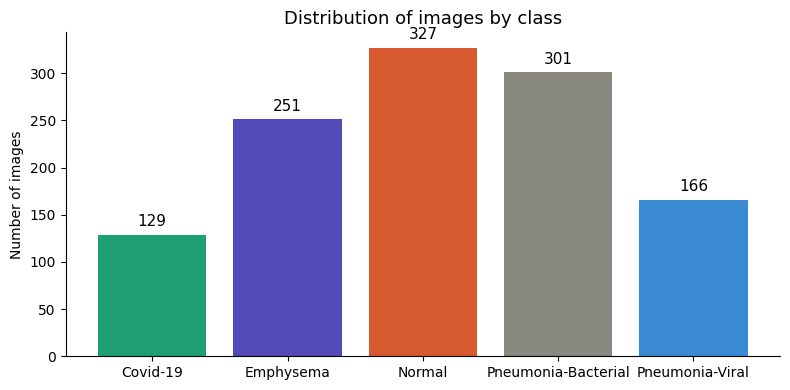

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=['#1D9E75','#534AB7','#D85A30','#888780','#3B8BD4'])
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title('Distribution of images by class', fontsize=13)
ax.set_ylabel('Number of images')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

**Sample Images per Class**

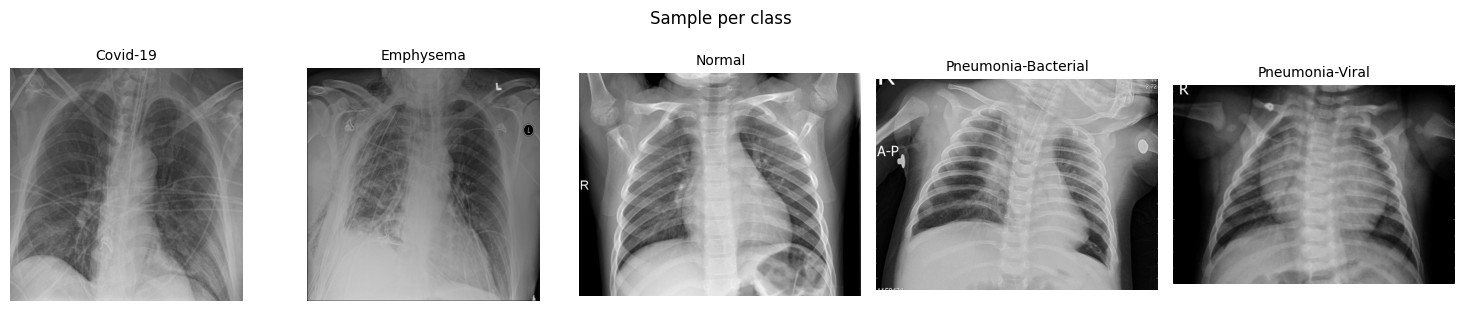

In [ ]:
from PIL import Image

fig, axes = plt.subplots(1, len(class_counts), figsize=(15, 3))
for ax, (cls_name, _) in zip(axes, class_counts.items()):
    for d in DATA_ROOT.rglob('*'):
        if d.is_dir() and d.name == cls_name:
            imgs = list(d.glob('*.jpg')) + list(d.glob('*.jpeg')) + list(d.glob('*.png'))
            if imgs:
                img = Image.open(random.choice(imgs)).convert('RGB')
                ax.imshow(img, cmap='gray')
                ax.set_title(cls_name, fontsize=10)
                ax.axis('off')
                break
plt.suptitle('Sample per class', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

**Verify Dataset Directory Structure**

In [ ]:
!find raw_data -type d | sort


raw_data
raw_data/Dataset_5_Class_Crop
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/test
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/test/Covid-19
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/test/Emphysema
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/test/Normal
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/test/Pneumonia-Bacterial
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/test/Pneumonia-Viral
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/train
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/train/Covid-19
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/train/Emphysema
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/train/Normal
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/train/Pneumonia-Bacterial
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/train/Pneumonia-Viral
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/val
raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop/va

**Verify Dataset Split**

In [ ]:
from pathlib import Path

BASE = Path('raw_data/Dataset_5_Class_Crop/Dataset_5_Class_Crop')

CLASSES = ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

# Verification
for split in ['train', 'val', 'test']:
    print(f'\n{split}:')
    for cls in CLASSES:
        n = len(list((BASE / split / cls).glob('*')))
        print(f'  {cls:25s}: {n} images')


train:
  Covid-19                 : 2417 images
  Emphysema                : 2050 images
  Normal                   : 2671 images
  Pneumonia-Bacterial      : 2400 images
  Pneumonia-Viral          : 2413 images

val:
  Covid-19                 : 300 images
  Emphysema                : 250 images
  Normal                   : 300 images
  Pneumonia-Bacterial      : 300 images
  Pneumonia-Viral          : 300 images

test:
  Covid-19                 : 300 images
  Emphysema                : 250 images
  Normal                   : 300 images
  Pneumonia-Bacterial      : 300 images
  Pneumonia-Viral          : 300 images


**Data Preprocessing and Augmentation**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE   = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05,
    brightness_range=[0.85, 1.15],
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    BASE / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=True,
)
val_gen = val_datagen.flow_from_directory(
    BASE / 'val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False,
)
test_gen = val_datagen.flow_from_directory(
    BASE / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False,
)

labels = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(cw))
print('\nClass weights:')
for k, v in class_weight_dict.items():
    print(f'  {CLASSES[k]:25s}: {v:.3f}')

Found 11951 images belonging to 5 classes.
Found 1450 images belonging to 5 classes.
Found 1450 images belonging to 5 classes.

Class weights:
  Covid-19                 : 0.989
  Emphysema                : 1.166
  Normal                   : 0.895
  Pneumonia-Bacterial      : 0.996
  Pneumonia-Viral          : 0.991


**Model Architecture (DenseNet-121)**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121

NUM_CLASSES = 5

def build_model(trainable_base=False):
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = trainable_base

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return keras.Model(inputs, outputs), base

model, base_model = build_model(trainable_base=False)
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,285 (27.87 MB)

 Trainable params: 265,733 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

**Model Compilation and Initial Training**

In [ ]:
EPOCHS_FROZEN = 15

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc', multi_label=False)],
)

callbacks_p1 = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                   monitor='val_auc', mode='max'),
    keras.callbacks.ModelCheckpoint('best_phase1.keras', save_best_only=True,
                                     monitor='val_auc', mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, min_lr=1e-6),
]

print('=== Phase 1: Training head only ===')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1,
)

=== Phase 1: Training head only ===
Epoch 1/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 268s 636ms/step - accuracy: 0.7103 - auc: 0.9360 - loss: 0.7547 - val_accuracy: 0.7710 - val_auc: 0.9603 - val_loss: 0.5811 - learning_rate: 0.0010
Epoch 2/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 201s 538ms/step - accuracy: 0.7681 - auc: 0.9573 - loss: 0.5992 - val_accuracy: 0.7931 - val_auc: 0.9659 - val_loss: 0.5370 - learning_rate: 0.0010
Epoch 3/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 197s 526ms/step - accuracy: 0.7845 - auc: 0.9631 - loss: 0.5571 - val_accuracy: 0.7669 - val_auc: 0.9593 - val_loss: 0.6061 - learning_rate: 0.0010
Epoch 4/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 196s 525ms/step - accuracy: 0.7914 - auc: 0.9643 - loss: 0.5487 - val_accuracy: 0.7903 - val_auc: 0.9640 - val_loss: 0.5718 - learning_rate: 0.0010
Epoch 5/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 198s 529ms/step - accuracy: 0.8009 - auc: 0.9678 - loss: 0.5240 - val_accuracy: 0.7648 - val_auc: 0.9572 - val_loss: 0.6418 - learning_rate: 0.0010
Epoch 6/15
374/374 ━━━━━

**Fine-Tuning**


In [ ]:
EPOCHS_FINETUNE = 25

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc', multi_label=False)],
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True,
                                   monitor='val_auc', mode='max'),
    keras.callbacks.ModelCheckpoint('best_final.keras', save_best_only=True,
                                     monitor='val_auc', mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, min_lr=1e-8),
]

print('=== Phase 2: Fine-tuning ===')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight_dict,
    callbacks=callbacks_p2,
)

=== Phase 2: Fine-tuning ===
Epoch 1/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 270s 625ms/step - accuracy: 0.8291 - auc: 0.9755 - loss: 0.4577 - val_accuracy: 0.8241 - val_auc: 0.9734 - val_loss: 0.4873 - learning_rate: 1.0000e-05
Epoch 2/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 199s 532ms/step - accuracy: 0.8284 - auc: 0.9756 - loss: 0.4552 - val_accuracy: 0.8283 - val_auc: 0.9739 - val_loss: 0.4829 - learning_rate: 1.0000e-05
Epoch 3/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 197s 527ms/step - accuracy: 0.8379 - auc: 0.9772 - loss: 0.4422 - val_accuracy: 0.8221 - val_auc: 0.9736 - val_loss: 0.4867 - learning_rate: 1.0000e-05
Epoch 4/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 194s 519ms/step - accuracy: 0.8388 - auc: 0.9784 - loss: 0.4316 - val_accuracy: 0.8255 - val_auc: 0.9740 - val_loss: 0.4837 - learning_rate: 1.0000e-05
Epoch 5/25
374/374 ━━━━━━━━━━━━━━━━━━━━ 194s 518ms/step - accuracy: 0.8374 - auc: 0.9775 - loss: 0.4385 - val_accuracy: 0.8283 - val_auc: 0.9743 - val_loss: 0.4764 - learning_rate: 1.0000e-05
Epoch 6/25


**Training Performance Visualization**

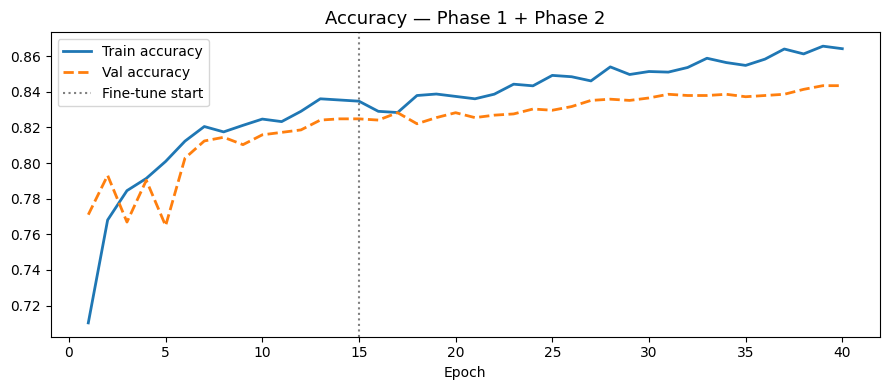

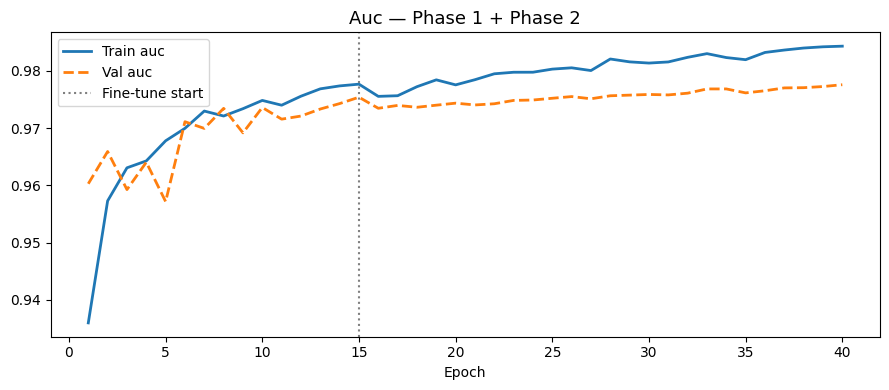

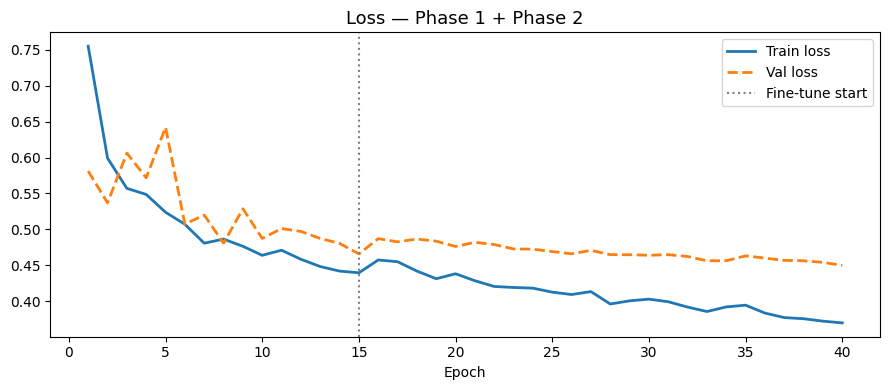

In [ ]:
def plot_combined(h1, h2, metric):
    combined_train = h1.history[metric]      + h2.history[metric]
    combined_val   = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    split_epoch    = len(h1.history[metric])
    epochs         = range(1, len(combined_train) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(epochs, combined_train, label=f'Train {metric}', linewidth=2)
    plt.plot(epochs, combined_val,   label=f'Val {metric}', linewidth=2, linestyle='--')
    plt.axvline(split_epoch, color='gray', linestyle=':', label='Fine-tune start')
    plt.title(f'{metric.capitalize()} — Phase 1 + Phase 2', fontsize=13)
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'curve_{metric}.png', dpi=150)
    plt.show()

plot_combined(history1, history2, 'accuracy')
plot_combined(history1, history2, 'auc')
plot_combined(history1, history2, 'loss')

**Model Evaluation on Test Set**

46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 348ms/step - accuracy: 0.8572 - auc: 0.9812 - loss: 0.4052

Test Loss:     0.4052
Test Accuracy: 0.8572
Test AUC:      0.9812
46/46 ━━━━━━━━━━━━━━━━━━━━ 29s 405ms/step

Classification Report:
                     precision    recall  f1-score   support

           Covid-19      0.961     0.910     0.935       300
          Emphysema      0.899     0.960     0.928       250
             Normal      0.834     0.990     0.905       300
Pneumonia-Bacterial      0.762     0.810     0.785       300
    Pneumonia-Viral      0.848     0.633     0.725       300

           accuracy                          0.857      1450
          macro avg      0.861     0.861     0.856      1450
       weighted avg      0.860     0.857     0.853      1450



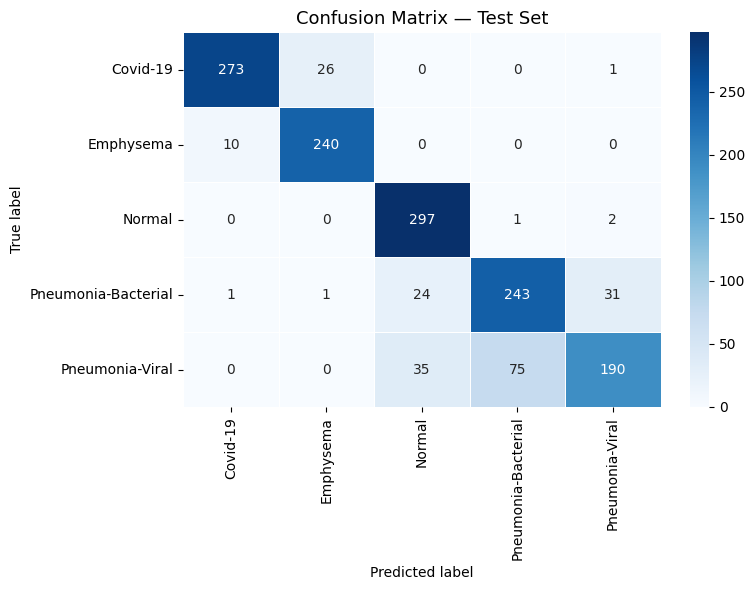

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model = keras.models.load_model('best_final.keras')

test_gen.reset()
results = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss:     {results[0]:.4f}')
print(f'Test Accuracy: {results[1]:.4f}')
print(f'Test AUC:      {results[2]:.4f}')

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

**Label Smoothing**

In [ ]:
# 1. Label smoothing — reduce overconfidence
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)



**Grad-CAM Visualization**

In [ ]:
import tensorflow as tf
import matplotlib.cm as mplcm
import cv2

def make_gradcam(img_array, model, class_idx=None):

    img_tensor = tf.cast(img_array, tf.float32)

    # We find the last Conv2D layer of the base model
    base = next(l for l in model.layers if hasattr(l, 'layers'))
    last_conv = next(l for l in reversed(base.layers)
                     if isinstance(l, tf.keras.layers.Conv2D))
    last_conv_name = last_conv.name

   # Model that produces conv features
    feature_extractor = tf.keras.Model(
        inputs=base.input,
        outputs=last_conv.output
    )

    with tf.GradientTape() as tape:
       # We get conv features
        conv_out = feature_extractor(img_tensor, training=False)
        tape.watch(conv_out)

      # We pass the features through the remaining layers of the model
        x = conv_out
        # Global Average Pooling + Dense layers (ό,τι υπάρχει μετά το base)
        preds = model(img_tensor, training=False)

        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))

        score = preds[:, class_idx]

    grads = tape.gradient(score, conv_out)

   # Fallback if gradients are None
    if grads is None:
        print(f'⚠️ Δοκιμάζω fallback method...')
        return make_gradcam_fallback(img_array, model, class_idx)

    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), class_idx, preds[0].numpy()


def make_gradcam_fallback(img_array, model, class_idx=None):

    img_tensor = tf.Variable(tf.cast(img_array, tf.float32))

    with tf.GradientTape() as tape:
        preds = model(img_tensor, training=False)
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        score = preds[:, class_idx]

   # Gradients relative to the input image (saliency map fallback)
    grads = tape.gradient(score, img_tensor)
    grads = tf.reduce_max(tf.abs(grads), axis=-1)
    heatmap = grads[0]
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), class_idx, preds[0].numpy()


def overlay_heatmap(img_pil, heatmap, alpha=0.45):
    img_rgb = np.array(img_pil)
    heat_rs = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    colored = (mplcm.jet(heat_rs)[:, :, :3] * 255).astype(np.uint8)
    overlay = cv2.addWeighted(img_rgb, 1 - alpha, colored, alpha, 0)
    return img_rgb, heat_rs, overlay


def gradcam_plot(img_path, model, alpha=0.45, save_path=None):
    img_pil = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = keras.utils.img_to_array(img_pil) / 255.0
    img_exp = np.expand_dims(img_arr, 0)

    heatmap, pred_idx, probs = make_gradcam(img_exp, model)
    img_rgb, heat_rs, overlay = overlay_heatmap(img_pil, heatmap, alpha)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.suptitle(
        f'Prediction: {CLASSES[pred_idx].upper()}  ({probs[pred_idx]:.1%} confidence)\n'
        + '  '.join([f'{c}: {p:.1%}' for c, p in zip(CLASSES, probs)]),
        fontsize=11, y=1.02
    )
    axes[0].imshow(img_rgb, cmap='gray'); axes[0].set_title('X-Ray');    axes[0].axis('off')
    axes[1].imshow(heat_rs, cmap='jet');  axes[1].set_title('Grad-CAM'); axes[1].axis('off')
    axes[2].imshow(overlay);              axes[2].set_title('Overlay');   axes[2].axis('off')

    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
    plt.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04, label='Attention intensity')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return CLASSES[pred_idx], probs

print('Grad-CAM functions loaded ✓')

Grad-CAM functions loaded ✓


**Single Image Prediction and Visualization**

Upload one or more x-rays (jpg/png):


Saving COVID-1059.jpg to COVID-1059 (3).jpg

📄 File: COVID-1059 (3).jpg
⚠️ Δοκιμάζω fallback method...


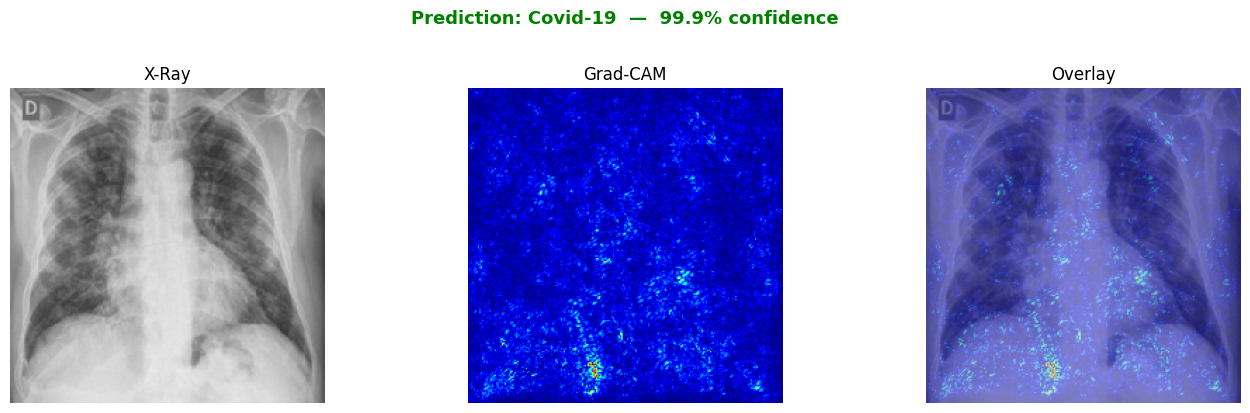

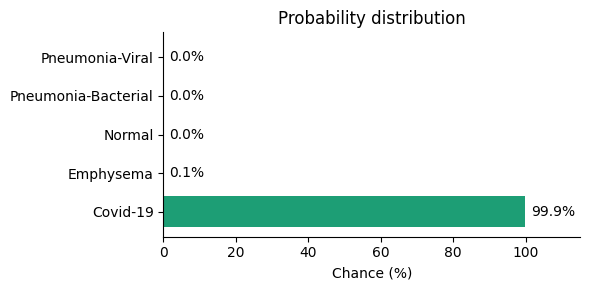


Result: Covid-19 (99.9%)
  Covid-19                  █████████████████████████████  99.9% ◄
  Emphysema                                                0.1%
  Normal                                                   0.0%
  Pneumonia-Bacterial                                      0.0%
  Pneumonia-Viral                                          0.0%


In [ ]:
from google.colab import files
import tensorflow as tf
import os

# Ensure the model is loaded
model_path = 'best_final.keras'
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Error: Model file '{model_path}' not found. Please ensure the model has been trained and saved successfully by running cells related to model training (e.g., cell `mZeDzzaBMPqc` and `4j0fdE5EX0m6`).")
model = tf.keras.models.load_model(model_path)

def predict_and_show(img_path, model):
    img_pil = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = keras.utils.img_to_array(img_pil) / 255.0
    img_exp = np.expand_dims(img_arr, 0)

    # Prediction
    probs    = model.predict(img_exp, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_cls = CLASSES[pred_idx]
    conf     = probs[pred_idx]

    # Grad-CAM
    try:
        heatmap, _, _ = make_gradcam(img_exp, model, class_idx=pred_idx)
        img_rgb, heat_rs, overlay = overlay_heatmap(img_pil, heatmap)
        has_gradcam = True
    except Exception as e:
        print(f'⚠️ Grad-CAM failed: {e}')
        has_gradcam = False

    # Image plot
    if has_gradcam:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(np.array(img_pil), cmap='gray')
        axes[0].set_title('X-Ray');    axes[0].axis('off')
        axes[1].imshow(heat_rs, cmap='jet')
        axes[1].set_title('Grad-CAM'); axes[1].axis('off')
        axes[2].imshow(overlay)
        axes[2].set_title('Overlay');  axes[2].axis('off')
    else:
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(np.array(img_pil), cmap='gray')
        ax.axis('off')

    color = 'green' if conf > 0.85 else 'orange' if conf > 0.65 else 'red'
    fig.suptitle(
        f'Prediction: {pred_cls}  —  {conf:.1%} confidence',
        fontsize=13, fontweight='bold', color=color, y=1.02
    )
    plt.tight_layout()
    plt.show()

    #  Probability bar chart
    fig2, ax2 = plt.subplots(figsize=(6, 3))
    colors = ['#1D9E75' if i == pred_idx else '#D3D1C7' for i in range(len(CLASSES))]
    bars = ax2.barh(CLASSES, probs * 100, color=colors)
    ax2.bar_label(bars, fmt='%.1f%%', padding=4)
    ax2.set_xlim(0, 115)
    ax2.set_xlabel('Chance (%)')
    ax2.set_title('Probability distribution')
    ax2.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    #  Text output
    print(f'\nResult: {pred_cls} ({conf:.1%})')
    for i, (cls, p) in enumerate(zip(CLASSES, probs)):
        bar  = '█' * int(p * 30)
        mark = ' ◄' if i == pred_idx else ''
        print(f'  {cls:25s} {bar:<30s} {p:.1%}{mark}')

    return pred_cls, probs


#  Upload & run
print('Upload one or more x-rays (jpg/png):')
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\n{"="*55}')
    print(f'📄 File: {filename}')
    print('='*55)
    predict_and_show(filename, model)